In [32]:
from datasets import load_dataset
data = load_dataset("json", data_files="dataset.json")

In [46]:
import numpy
data["train"][600000]["image"]
test = torch.tensor(data["train"][0]["image"])
test2 = np.array(data["train"][0]["image"], dtype=np.uint8 )

In [42]:
import torch.nn as nn 
import torch.nn.functional as F

# Simple neural network to model brain of sheep, 2 classes: predator or not
class Brain(nn.Module):
    def __init__(self, in_channels = 1, num_classes=2):
        super(Brain, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  
        x = self.pool(x)           
        x = F.relu(self.conv2(x))  
        x = self.pool(x)           
        x = x.reshape(x.shape[0], -1)  
        x = self.fc1(x)            
        return x

brain = Brain()


In [50]:
test.shape

torch.Size([28, 28])

In [51]:
brain(test.reshape(1, 1, 28, 28).float())

tensor([[-18.2807,  -3.8484]], grad_fn=<AddmmBackward0>)

In [28]:
import torch
test = torch.tensor(data["train"][0]["image"])
test2 = np.array(data["train"][0]["image"], dtype=np.uint8 )

In [29]:
test2

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [31]:
from PIL import Image
image = Image.fromarray(test2)
print(data["train"][0]["name"])
image.show()

crocodile


sheep


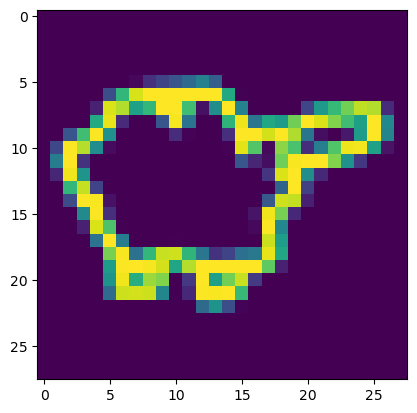

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
random = np.random.randint(0, 10000)
image = Image.fromarray(reshaped[4][random])
print(names[4])
plt.imshow(image)

In [9]:
len(reshaped[0])

127932

In [14]:
test = []
entry = {}
for animal in reshaped:
    count = 0
    for i in range(len(animal)):
        if count < 1000:
            count += 1
        entry["image"] = animal[i]
        if animal != reshaped[3] or animal != reshaped[4]:
            entry["class"] = 1
        else:
            entry["class"] = 0
        entry["name"] = "test"
        test.append(entry)

In [24]:
image = Image.fromarray(test[0]["image"])
image.show()

In [1]:
import torch.nn as nn 
import torch.nn.functional as F

# Simple neural network to model brain of sheep, 2 classes: predator or not
class Brain(nn.Module):
    def __init__(self, in_channels = 1, num_classes=2):
        super(Brain, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  
        x = self.pool(x)           
        x = F.relu(self.conv2(x))  
        x = self.pool(x)           
        x = x.reshape(x.shape[0], -1)  
        x = self.fc1(x)            
        return x

brain = Brain()


In [59]:
data1 = torch.tensor(reshaped[4][1])
data2 = torch.tensor(reshaped[4][2])

combined = torch.stack((data1.unsqueeze(0), data2.unsqueeze(0))).float()

<module 'torch' from 'c:\\Users\\allan\\Anaconda3\\envs\\evolution\\Lib\\site-packages\\torch\\__init__.py'>

In [63]:
import torch 
brain(combined)

probs = F.softmax(brain(combined), dim=1)
print(probs)

tensor([[1.0000e+00, 8.6724e-11],
        [1.0000e+00, 7.8659e-15]], grad_fn=<SoftmaxBackward0>)
